# Brain Tumor Classification using CNN

In [1]:
import tensorflow as tf
tf.config.threading.set_inter_op_parallelism_threads(6)
tf.config.threading.set_intra_op_parallelism_threads(12)

c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Import Necessary Library

In [2]:
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, MaxPool2D, Conv2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.21.0


In [3]:
# 2. CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = "Dataset/Training"
TEST_DIR = "Dataset/Testing"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

MODEL_DIR = "models"
VIS_DIR = "visualization"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print("Train directory:", TRAIN_DIR)
print("Test directory :", TEST_DIR)

Train directory: Dataset/Training
Test directory : Dataset/Testing


# 3. Dataset Overview

Before training, we inspect the number of images in every class and visualize the class distribution.

In [4]:
# 3. COUNT IMAGES IN TRAIN AND TEST
# ============================================================

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def count_images(folder):
    counts = {}

    for class_name in CLASS_NAMES:
        class_dir = os.path.join(folder, class_name)

        if os.path.exists(class_dir):
            counts[class_name] = sum(
                1 for f in os.listdir(class_dir)
                if f.lower().endswith(VALID_EXTENSIONS)
            )
        else:
            counts[class_name] = 0

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN DATA")
for cls, count in train_counts.items():
    print(f"{cls:12s}: {count}")

print("\nTEST DATA")
for cls, count in test_counts.items():
    print(f"{cls:12s}: {count}")

TRAIN DATA
glioma      : 1400
meningioma  : 1400
notumor     : 1400
pituitary   : 1400

TEST DATA
glioma      : 400
meningioma  : 400
notumor     : 400
pituitary   : 400


,Class,Train,Test
0,glioma,1400,400
1,meningioma,1400,400
2,notumor,1400,400
3,pituitary,1400,400


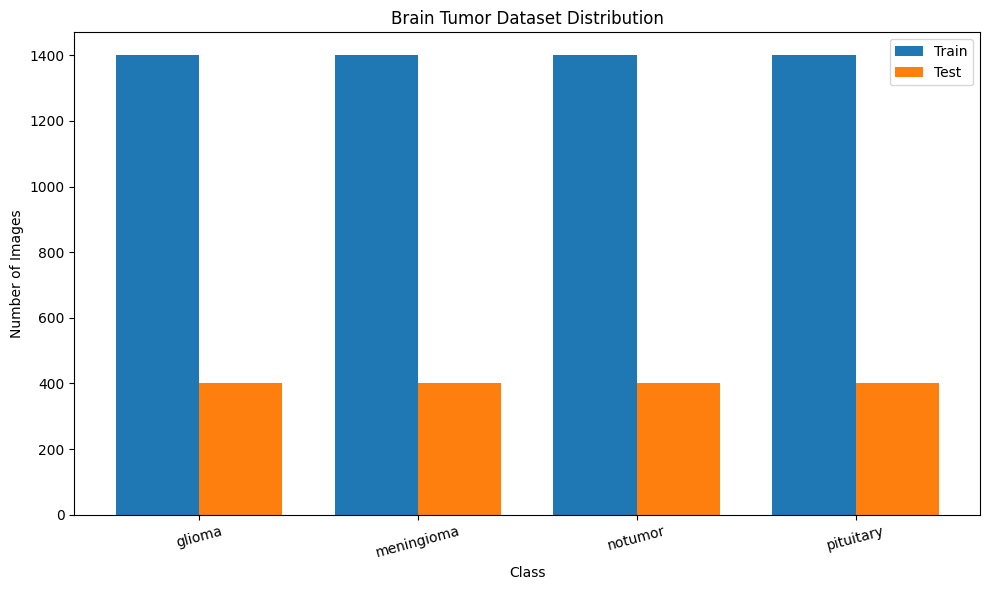

In [5]:
# 4. CLASS DISTRIBUTION VISUALIZATION
# ============================================================

distribution_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Train": [train_counts[c] for c in CLASS_NAMES],
    "Test": [test_counts[c] for c in CLASS_NAMES]
})

display(distribution_df)

x = np.arange(len(CLASS_NAMES))
width = 0.38

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, distribution_df["Train"], width, label="Train")
plt.bar(x + width/2, distribution_df["Test"], width, label="Test")

plt.title("Brain Tumor Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(x, CLASS_NAMES, rotation=15)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "class_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Sample MRI Images

The following visualization displays representative images from all four classes.

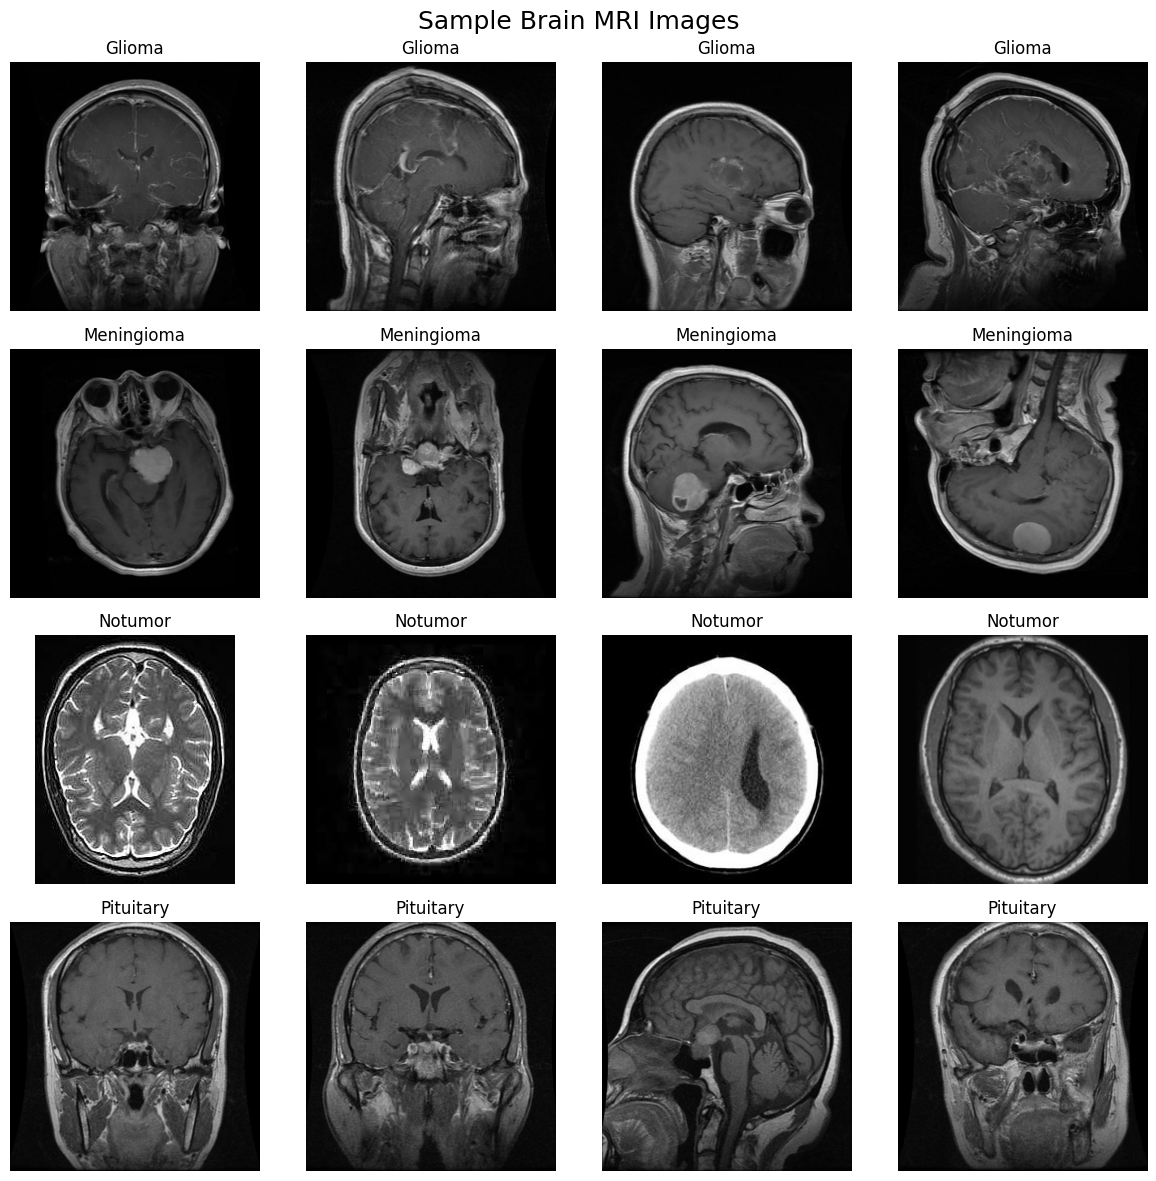

In [6]:
# 5. SAMPLE IMAGES
# ============================================================

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    4,
    figsize=(12, 12)
)

for row, class_name in enumerate(CLASS_NAMES):

    class_dir = os.path.join(TRAIN_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(VALID_EXTENSIONS)
    ]

    image_files = image_files[:4]

    for col in range(4):

        ax = axes[row, col]

        if col < len(image_files):

            image_path = os.path.join(
                class_dir,
                image_files[col]
            )

            image = Image.open(image_path).convert("RGB")

            ax.imshow(image)
            ax.set_title(
                class_name.replace("_", " ").title()
            )

        ax.axis("off")

plt.suptitle(
    "Sample Brain MRI Images",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "sample_images.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Data Preprocessing & Augmentation

Training images are augmented to improve generalization.

The validation set is created from the **Train** directory only. The **Test** directory remains completely separate for final evaluation.

In [7]:
# 6. DATA GENERATORS
# ============================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class indices:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [8]:
# 7. CHECK DATASET SIZES
# ============================================================

print("Training images  :", train_generator.samples)
print("Test images      :", test_generator.samples)
print("Classes          :", train_generator.num_classes)

Training images  : 5600
Test images      : 1600
Classes          : 4


# 8. CNN Model Architecture

The CNN uses:

- Convolutional layers
- Batch Normalization
- Max Pooling
- Dropout
- Global Average Pooling
- Dense classification layer
- Softmax output for four classes

In [9]:
# 8. BUILD CNN MODEL
# ============================================================

model = models.Sequential([

    layers.Input(shape=(*IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.1),

    layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,196 (500.77 KB)

 Trainable params: 127,748 (499.02 KB)

 Non-trainable params: 448 (1.75 KB)

# 9. Training Configuration

The best model is saved based on validation accuracy.

Early stopping and learning-rate reduction help reduce overfitting and improve training stability.

In [10]:
# 9. CALLBACKS
# ============================================================

callbacks = [

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        os.path.join(
            MODEL_DIR,
            "brain_tumor_cnn.keras"
        ),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# 10. Train the CNN

In [11]:
# 10. TRAIN MODEL
# ============================================================

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Save training history for reproducibility
np.save(
    "history.npy",
    history.history
)

print("Training completed.")

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6212 - loss: 0.9226
Epoch 1: val_accuracy improved from None to 0.25000, saving model to models\brain_tumor_cnn.keras

Epoch 1: finished saving model to models\brain_tumor_cnn.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.6693 - loss: 0.8084 - val_accuracy: 0.2500 - val_loss: 4.1231 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7382 - loss: 0.6493
Epoch 2: val_accuracy improved from 0.25000 to 0.28125, saving model to models\brain_tumor_cnn.keras

Epoch 2: finished saving model to models\brain_tumor_cnn.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.7502 - loss: 0.6352 - val_accuracy: 0.2812 - val_loss: 5.7812 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7772 - loss: 0.5772
Epoch 3: val_accuracy improved from 0.28125 to 0.51875, saving model to models\brain_tumor_cnn.keras

Epoch 3: finished saving model t

# 11. Training Visualization

These plots show whether the model is learning effectively and whether overfitting is occurring.

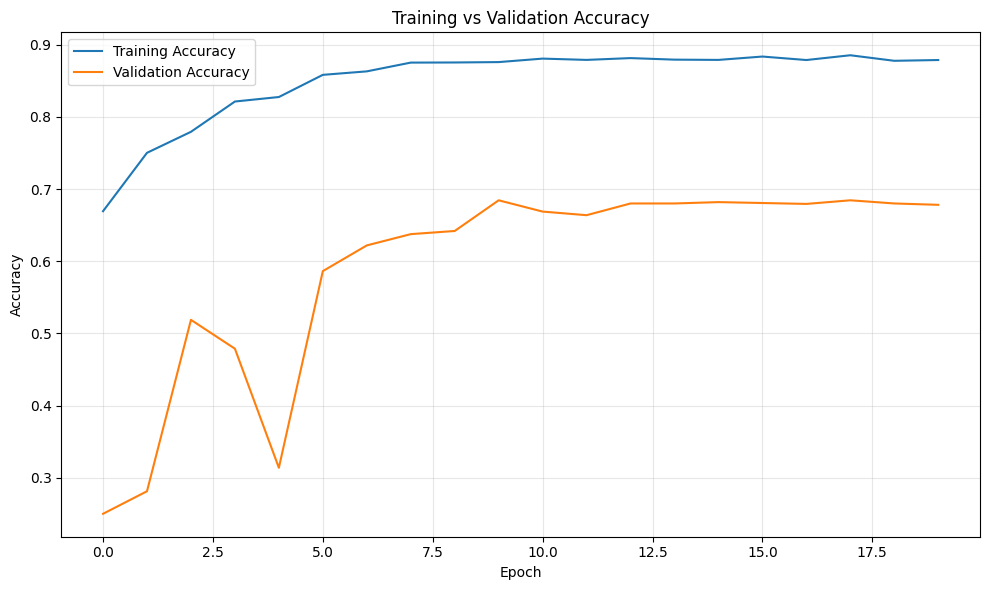

In [12]:
# 11. ACCURACY CURVE
# ============================================================

history_data = history.history

plt.figure(figsize=(10, 6))

plt.plot(
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

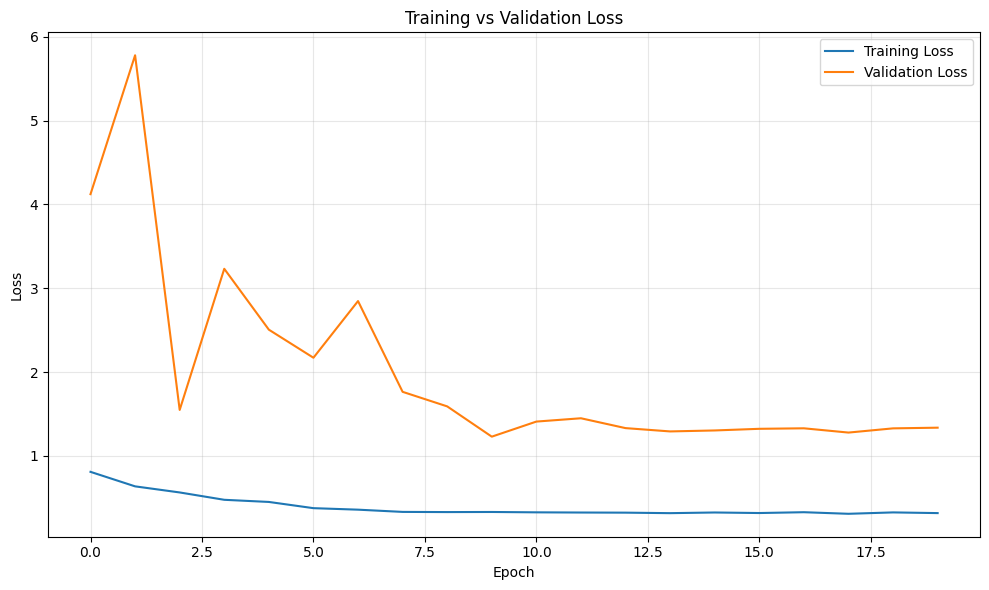

In [13]:
# 12. LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    history_data["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "loss_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 13. Final Test Evaluation

The test dataset is used only after training is complete.

In [14]:
# 13. TEST EVALUATION
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.6781 - loss: 1.3356

Test Loss     : 1.3356
Test Accuracy : 0.6781
Test Accuracy : 67.81%


# 14. Confusion Matrix

The confusion matrix shows how many images from each class were correctly and incorrectly classified.

In [15]:
# 14. PREDICTIONS
# ============================================================

test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Class labels:")
print(class_labels)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step
Class labels:
['glioma', 'meningioma', 'notumor', 'pituitary']


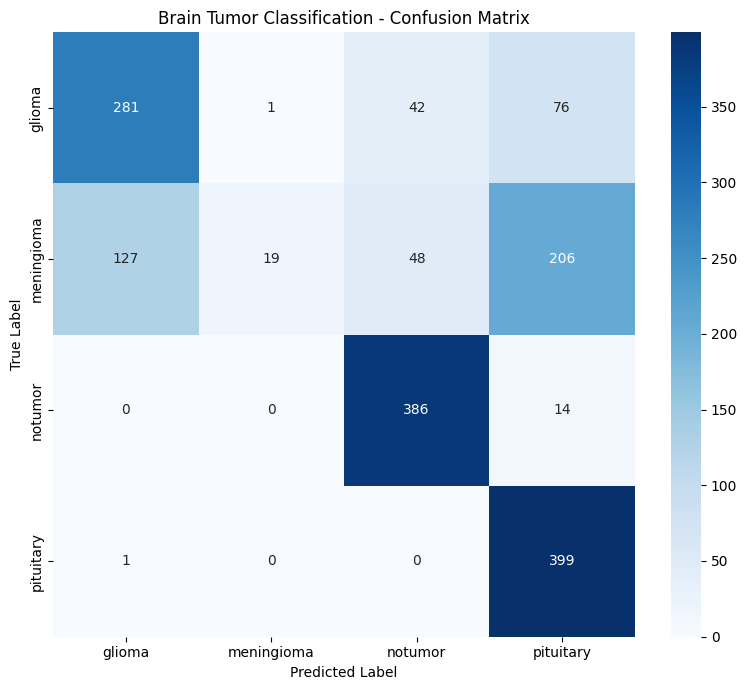

In [16]:
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Brain Tumor Classification - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 16. Classification Report

Precision, recall and F1-score are calculated for every tumor class.

In [17]:
# 16. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=4
)

print(report)

with open(
    os.path.join(VIS_DIR, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df)

report_df.to_csv(
    os.path.join(
        VIS_DIR,
        "classification_report.csv"
    )
)

              precision    recall  f1-score   support

      glioma     0.6870    0.7025    0.6947       400
  meningioma     0.9500    0.0475    0.0905       400
     notumor     0.8109    0.9650    0.8813       400
   pituitary     0.5741    0.9975    0.7288       400

    accuracy                         0.6781      1600
   macro avg     0.7555    0.6781    0.5988      1600
weighted avg     0.7555    0.6781    0.5988      1600



,precision,recall,f1-score,support
glioma,0.687042,0.702500,0.694685,400.000000
meningioma,0.950000,0.047500,0.090476,400.000000
notumor,0.810924,0.965000,0.881279,400.000000
pituitary,0.574101,0.997500,0.728767,400.000000
accuracy,0.678125,0.678125,0.678125,0.678125
macro avg,0.755517,0.678125,0.598802,1600.000000
weighted avg,0.755517,0.678125,0.598802,1600.000000


# 17. Sample Predictions

The following cell displays test images with their predicted and actual labels.

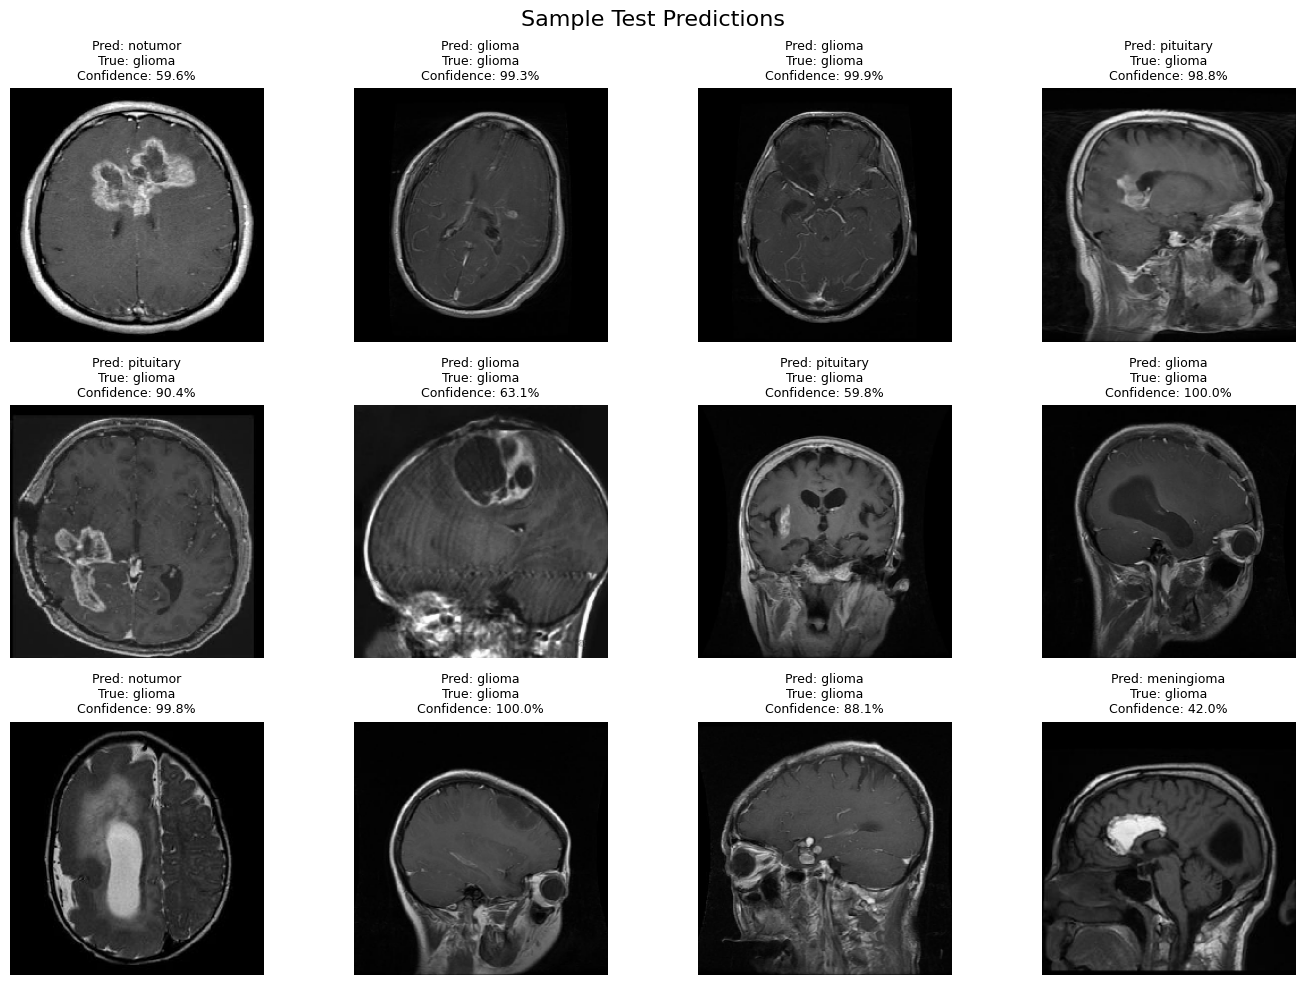

In [18]:
# 17. SAMPLE TEST PREDICTIONS
# ============================================================

test_generator.reset()

images, labels = next(test_generator)

preds = model.predict(images, verbose=0)

predicted_indices = np.argmax(preds, axis=1)
actual_indices = np.argmax(labels, axis=1)

plt.figure(figsize=(14, 10))

num_images = min(12, len(images))

for i in range(num_images):

    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i])

    predicted = class_labels[predicted_indices[i]]
    actual = class_labels[actual_indices[i]]

    confidence = preds[i][predicted_indices[i]] * 100

    title = (
        f"Pred: {predicted}\n"
        f"True: {actual}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.title(title, fontsize=9)

    plt.axis("off")

plt.suptitle(
    "Sample Test Predictions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(VIS_DIR, "sample_predictions.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 18. Save Final Model

The best model is already saved automatically by `ModelCheckpoint`.

In [19]:
# 18. SAVE FINAL MODEL
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    "brain_tumor_cnn_final.keras"
)

model.save(final_model_path)

print("Final model saved to:")
print(final_model_path)

Final model saved to:
models\brain_tumor_cnn_final.keras
